In [1]:
# ============================================
# DAY 2 - DATA VISUALIZATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

print("DAY 2 - Charts")
print("Libraries loaded successfully.")

DAY 2 - Charts
Libraries loaded successfully.


In [2]:
# ============================================
# LOAD CLEANED DATASETS
# ============================================

customers = pd.read_csv("customers_cleaned.csv")
transactions = pd.read_csv("transactions_cleaned.csv")
fraud_alerts = pd.read_csv("fraud_alerts_cleaned.csv")
service_cases = pd.read_csv("service_cases_cleaned.csv")

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("Fraud Alerts:", fraud_alerts.shape)
print("Service Cases:", service_cases.shape)

Customers: (1200, 12)
Transactions: (7000, 15)
Fraud Alerts: (1100, 12)
Service Cases: (2500, 15)


In [3]:
# ============================================
# PREPARE TRANSACTION DATE
# ============================================

transactions["transaction_timestamp"] = pd.to_datetime(
    transactions["transaction_timestamp"],
    errors="coerce"
)

transactions["month"] = (
    transactions["transaction_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

print("Date preparation completed.")

Date preparation completed.


In [4]:
# ============================================
# MONTHLY TRANSACTION SUMMARY
# ============================================

monthly_transactions = (
    transactions
    .groupby("month")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_value=("amount", "sum"),
        average_value=("amount", "mean")
    )
    .reset_index()
)

monthly_transactions

,month,transaction_count,total_value,average_value
0,2025-01,316,565365.600,1789.131646
1,2025-02,343,682151.555,1988.780044
2,2025-03,337,732866.210,2174.677181
3,2025-04,342,688630.890,2013.540614
4,2025-05,354,695503.305,1964.698602
5,2025-06,324,569328.230,1757.185895
6,2025-07,326,698760.660,2143.437607
7,2025-08,326,611986.865,1877.260322
8,2025-09,354,669572.950,1891.449011
9,2025-10,323,560106.335,1734.075341


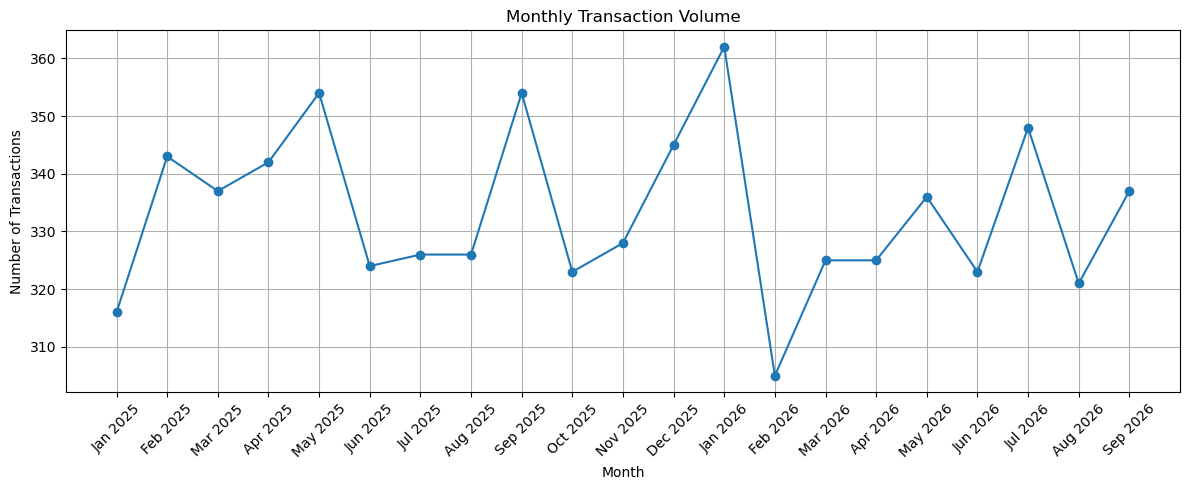

In [5]:
# ============================================
# CHART 1 - MONTHLY TRANSACTION VOLUME
# ============================================

# Convert month values to readable labels
monthly_transactions["month_label"] = pd.to_datetime(
    monthly_transactions["month"]
).dt.strftime("%b %Y")

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["month_label"],
    monthly_transactions["transaction_count"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

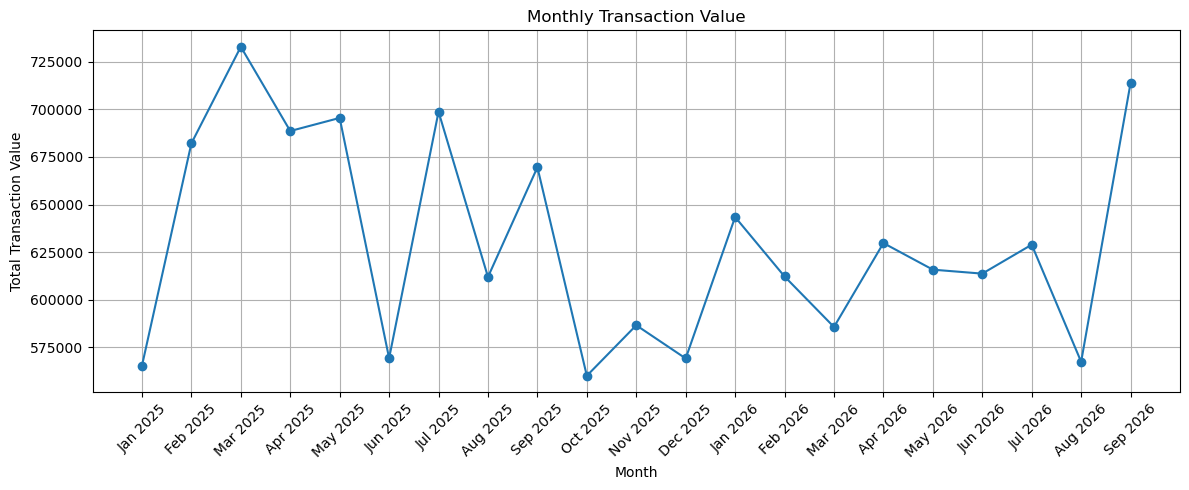

In [6]:
# ============================================
# CHART 2 - MONTHLY TRANSACTION VALUE
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["month_label"],
    monthly_transactions["total_value"],
    marker="o"
)

plt.title("Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Total Transaction Value")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

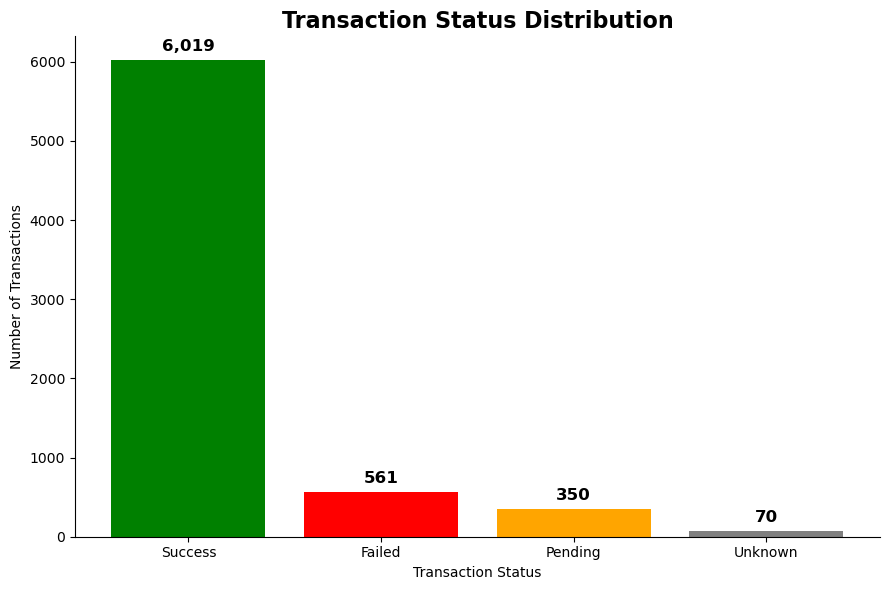

In [7]:
# ============================================
# CHART 3 - TRANSACTION STATUS DISTRIBUTION
# ============================================

status_counts = transactions["transaction_status"].value_counts()

# Colors for each status
colors = []

for status in status_counts.index:
    if status == "Success":
        colors.append("green")
    elif status == "Failed":
        colors.append("red")
    elif status == "Pending":
        colors.append("orange")
    else:
        colors.append("gray")

plt.figure(figsize=(9, 6))

bars = plt.bar(
    status_counts.index,
    status_counts.values,
    color=colors
)

# Add transaction numbers on top of bars
for bar, count in zip(bars, status_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Transaction Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")

# Remove grid lines
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

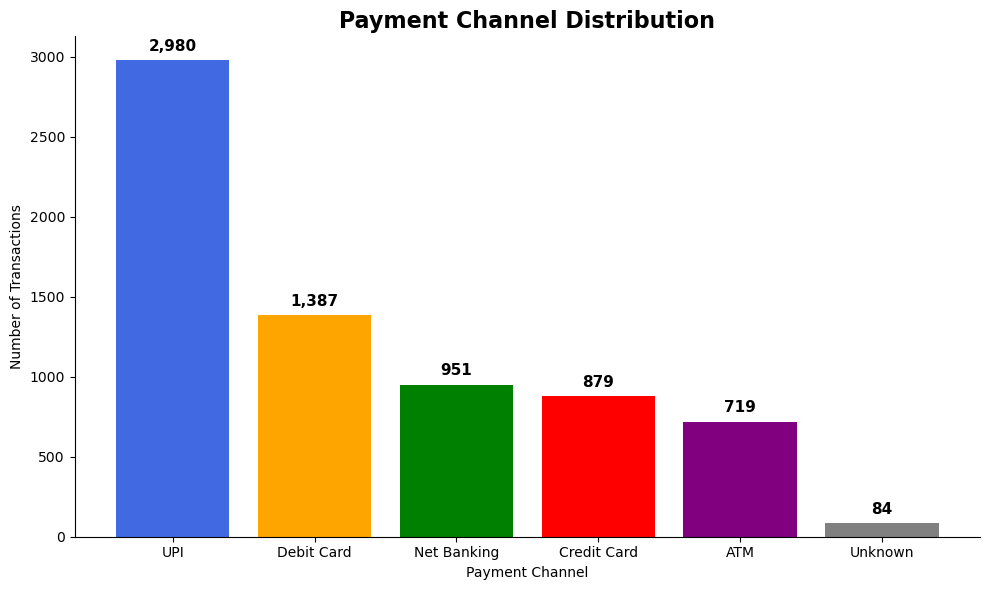

In [8]:
# ============================================
# CHART 4 - PAYMENT CHANNEL DISTRIBUTION
# ============================================

payment_counts = transactions["payment_channel"].value_counts()

# Different color for each payment channel
colors = [
    "royalblue",
    "orange",
    "green",
    "red",
    "purple",
    "gray"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    payment_counts.index,
    payment_counts.values,
    color=colors[:len(payment_counts)]
)

# Add transaction numbers on top of each bar
for bar, count in zip(bars, payment_counts.values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Payment Channel Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Channel")
plt.ylabel("Number of Transactions")

# Remove grid lines
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

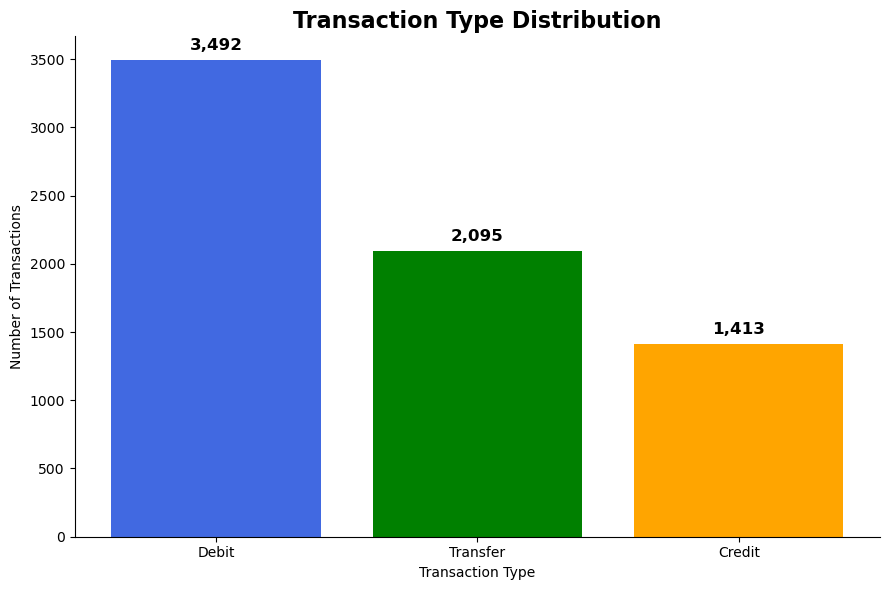

In [9]:
# ============================================
# CHART 5 - TRANSACTION TYPE DISTRIBUTION
# ============================================

transaction_type_counts = transactions["transaction_type"].value_counts()

# Colors for each transaction type
colors = [
    "royalblue",   # Debit
    "green",       # Transfer
    "orange"       # Credit
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    transaction_type_counts.index,
    transaction_type_counts.values,
    color=colors[:len(transaction_type_counts)]
)

# Add transaction numbers on top of each bar
for bar, count in zip(
    bars,
    transaction_type_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Transaction Type Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

# Remove grid lines
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

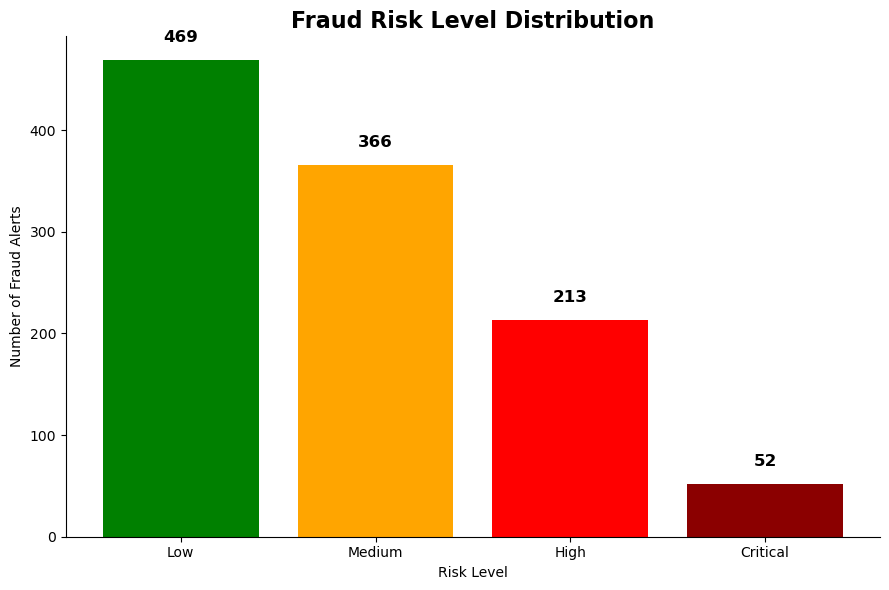

In [10]:
# ============================================
# CHART 6 - FRAUD RISK LEVEL DISTRIBUTION
# ============================================

risk_counts = fraud_alerts["risk_level"].value_counts()

# Colors for each risk level
colors = []

for risk in risk_counts.index:
    if risk == "Low":
        colors.append("green")
    elif risk == "Medium":
        colors.append("orange")
    elif risk == "High":
        colors.append("red")
    elif risk == "Critical":
        colors.append("darkred")
    else:
        colors.append("gray")

plt.figure(figsize=(9, 6))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=colors
)

# Add number of fraud alerts above each bar
for bar, count in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Fraud Risk Level Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Fraud Alerts")

# Remove grid lines
plt.grid(False)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

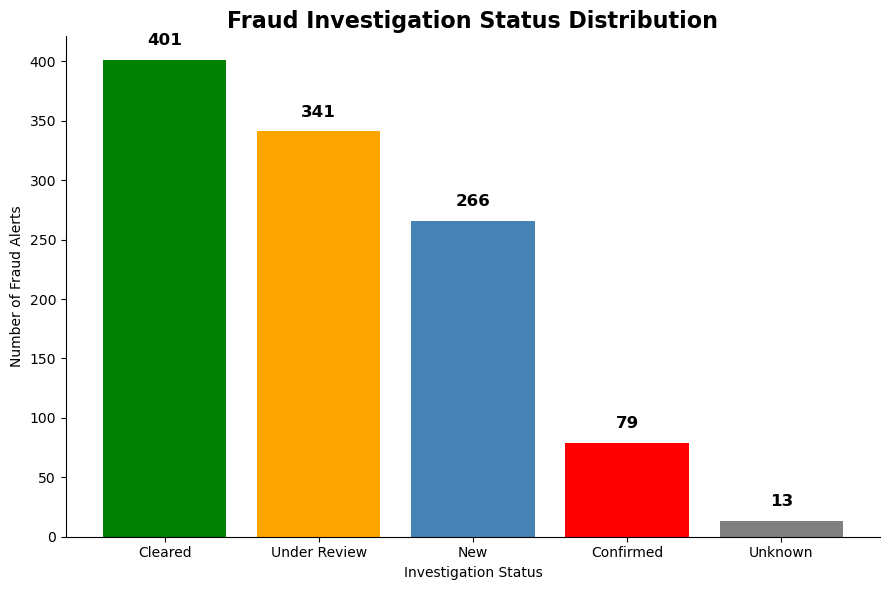

In [11]:
# ============================================
# CHART 7 - FRAUD INVESTIGATION STATUS
# ============================================

status_counts = fraud_alerts["investigation_status"].value_counts()

plt.figure(figsize=(9, 6))

bars = plt.bar(
    status_counts.index,
    status_counts.values,
    color=["green", "orange", "steelblue", "red", "gray"]
)

# Show number of alerts above each bar
for bar, count in zip(bars, status_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Fraud Investigation Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Investigation Status")
plt.ylabel("Number of Fraud Alerts")

# Remove grid lines
plt.grid(False)

# Clean chart appearance
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

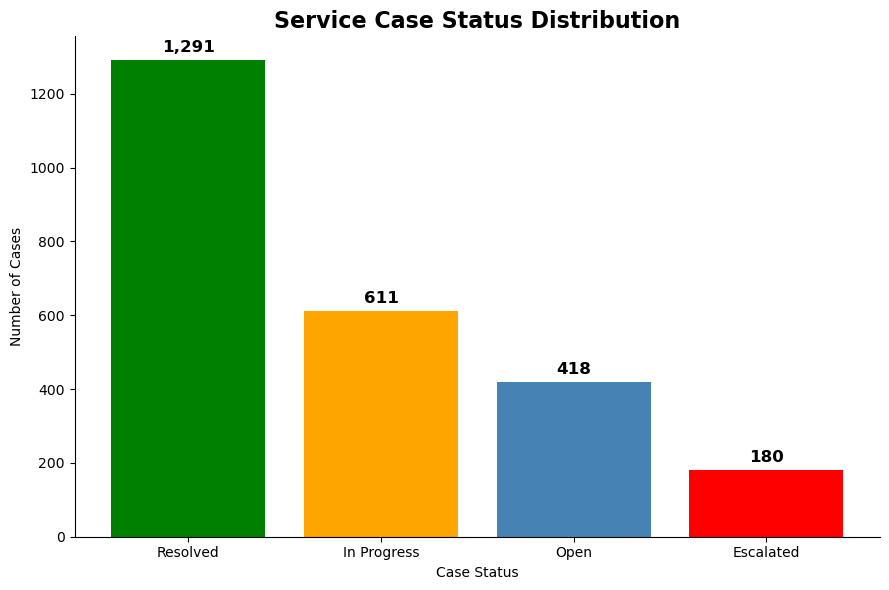

In [12]:
# ============================================
# CHART 8 - SERVICE CASE STATUS
# ============================================

case_status_counts = service_cases["status"].value_counts()

plt.figure(figsize=(9, 6))

bars = plt.bar(
    case_status_counts.index,
    case_status_counts.values,
    color=["green", "orange", "steelblue", "red"]
)

# Show number of cases above each bar
for bar, count in zip(bars, case_status_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Service Case Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Case Status")
plt.ylabel("Number of Cases")

# Remove grid lines
plt.grid(False)

# Clean appearance
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

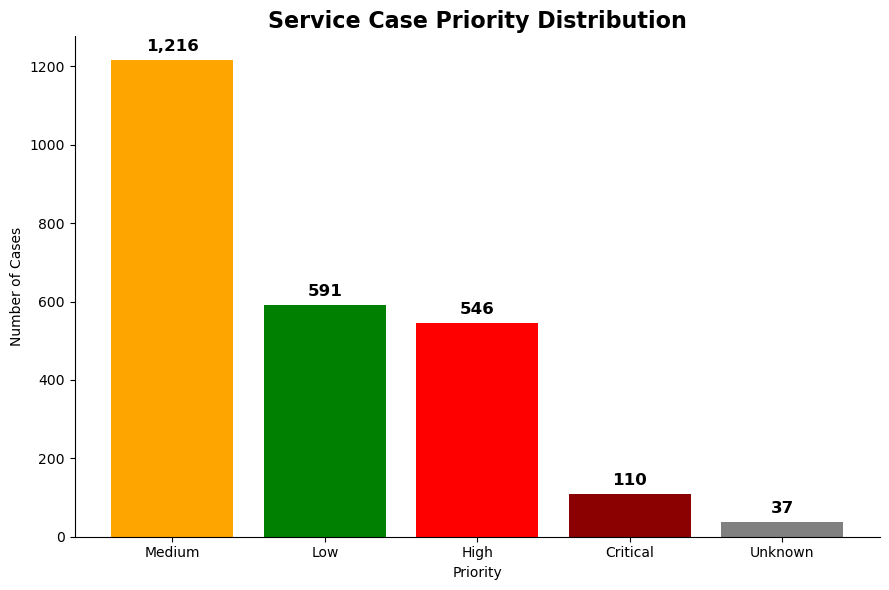

In [13]:
# ============================================
# CHART 9 - SERVICE CASE PRIORITY
# ============================================

priority_counts = service_cases["priority"].value_counts()

# Colors for each priority
colors = []

for priority in priority_counts.index:
    if priority == "Critical":
        colors.append("darkred")
    elif priority == "High":
        colors.append("red")
    elif priority == "Medium":
        colors.append("orange")
    elif priority == "Low":
        colors.append("green")
    else:
        colors.append("gray")

plt.figure(figsize=(9, 6))

bars = plt.bar(
    priority_counts.index,
    priority_counts.values,
    color=colors
)

# Show number of cases above each bar
for bar, count in zip(bars, priority_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Service Case Priority Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Priority")
plt.ylabel("Number of Cases")

# Remove grid lines
plt.grid(False)

# Clean appearance
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

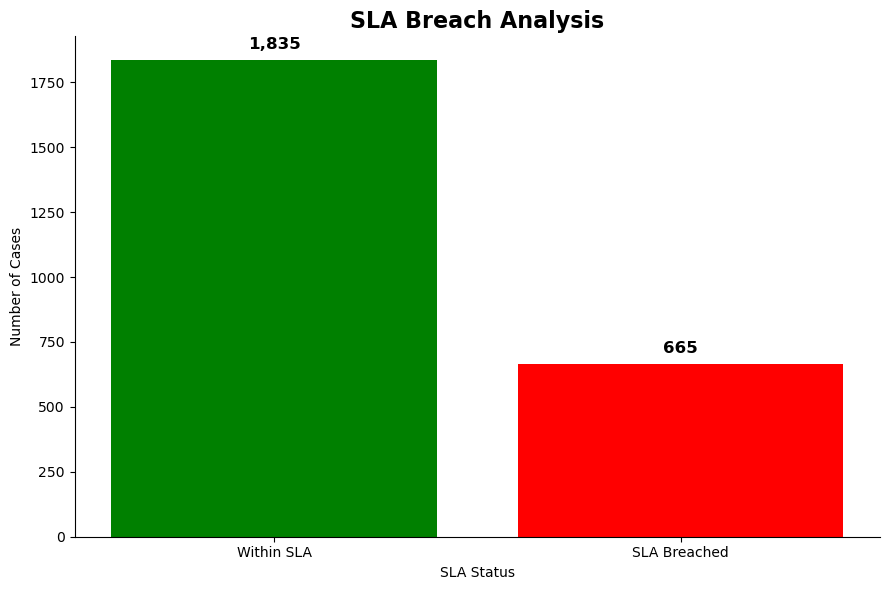

In [14]:
# Chart 10: SLA Breach Analysis

sla_counts = service_cases["sla_breached"].value_counts()

# Rename labels for better readability
sla_labels = []
for value in sla_counts.index:
    if value == True:
        sla_labels.append("SLA Breached")
    else:
        sla_labels.append("Within SLA")

# Colors
colors = ["green", "red"]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    sla_labels,
    sla_counts.values,
    color=colors[:len(sla_counts)]
)

# Add count labels
for bar, count in zip(bars, sla_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "SLA Breach Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("SLA Status")
plt.ylabel("Number of Cases")

# Remove grid
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

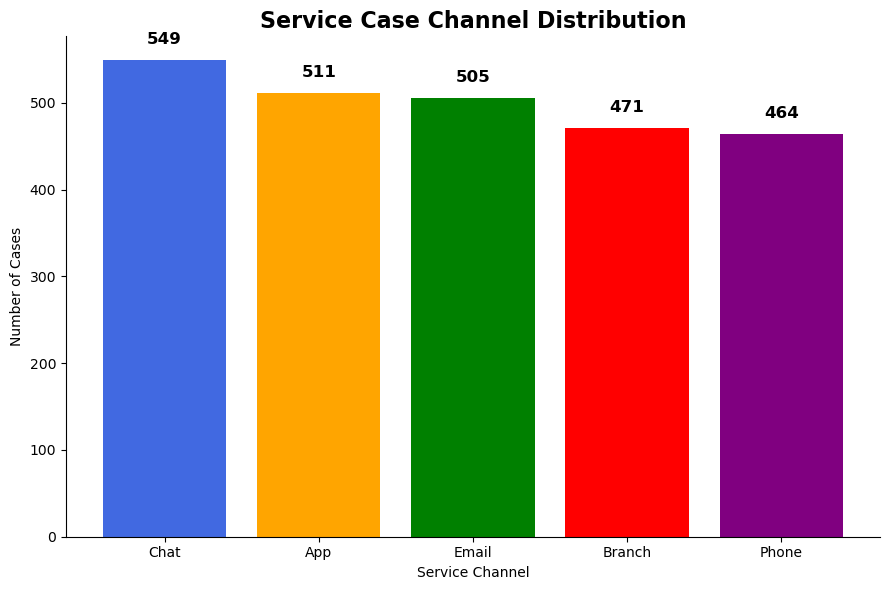

In [15]:
# Chart 11: Service Case Channel Distribution

channel_counts = service_cases["channel"].value_counts()

# Different colors
colors = ["royalblue", "orange", "green", "red", "purple"]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    channel_counts.index,
    channel_counts.values,
    color=colors[:len(channel_counts)]
)

# Add count labels
for bar, count in zip(bars, channel_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Service Case Channel Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Service Channel")
plt.ylabel("Number of Cases")

# Remove grid
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

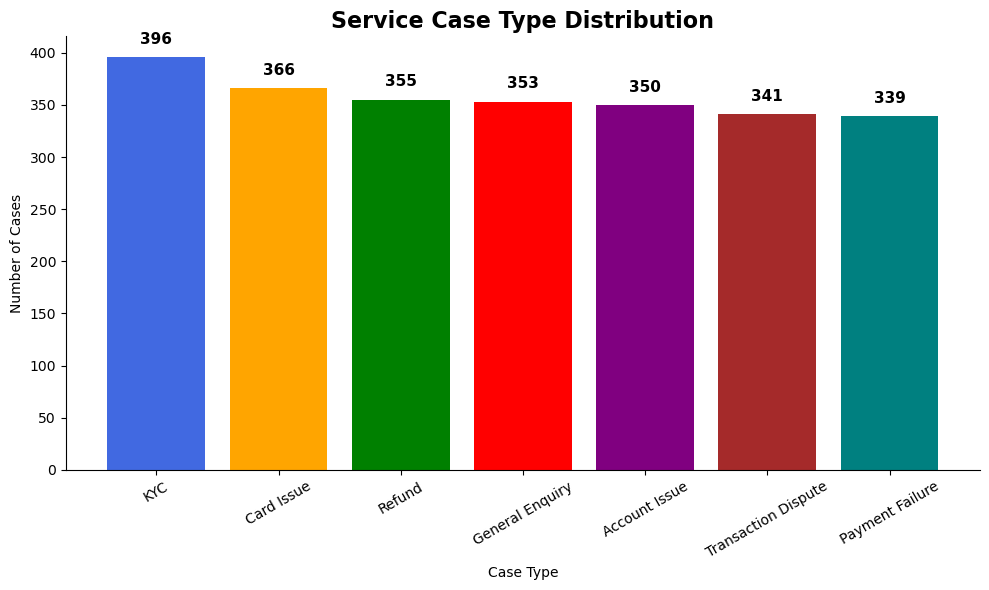

In [16]:
# Chart 12: Service Case Type Distribution

case_type_counts = service_cases["case_type"].value_counts()

# Different colors
colors = [
    "royalblue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "teal"
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    case_type_counts.index,
    case_type_counts.values,
    color=colors[:len(case_type_counts)]
)

# Add count labels
for bar, count in zip(bars, case_type_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Service Case Type Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Case Type")
plt.ylabel("Number of Cases")

# Remove grid
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Rotate labels if needed
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

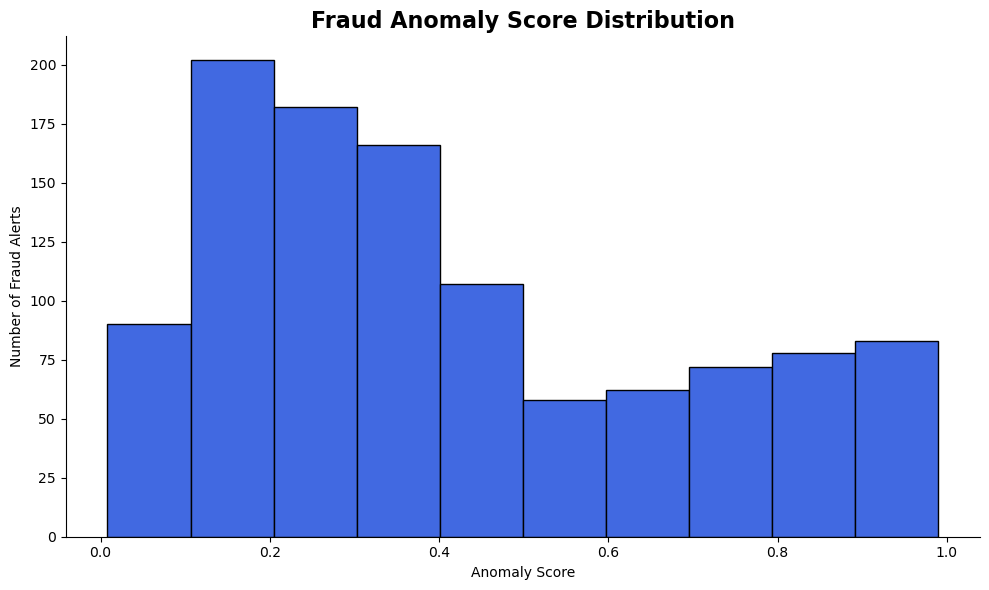

In [17]:
# Chart 13: Fraud Anomaly Score Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    fraud_alerts["anomaly_score"],
    bins=10,
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Fraud Anomaly Score Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Fraud Alerts")

# Remove grid
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

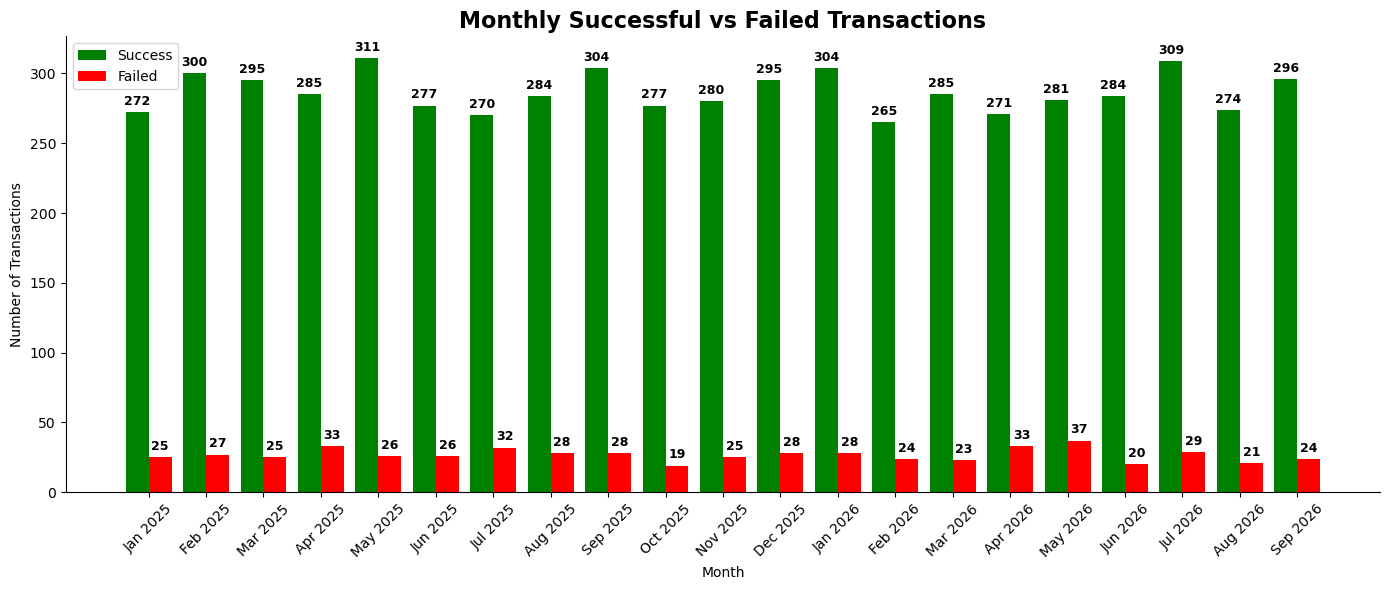

In [23]:
# Chart 14: Monthly Success vs Failed Transactions

monthly_status = (
    transactions[
        transactions["transaction_status"].isin(["Success", "Failed"])
    ]
    .groupby(["month", "transaction_status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Create readable month labels
monthly_status["month_label"] = pd.to_datetime(
    monthly_status["month"]
).dt.strftime("%b %Y")

# Create positions
x = range(len(monthly_status))
width = 0.4

plt.figure(figsize=(14, 6))

# Success bars
bars1 = plt.bar(
    [i - width/2 for i in x],
    monthly_status["Success"],
    width=width,
    color="green",
    label="Success"
)

# Failed bars
bars2 = plt.bar(
    [i + width/2 for i in x],
    monthly_status["Failed"],
    width=width,
    color="red",
    label="Failed"
)

# Add labels for Success
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Add labels for Failed
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    "Monthly Successful vs Failed Transactions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(
    list(x),
    monthly_status["month_label"],
    rotation=45
)

plt.legend()

# Remove grid
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

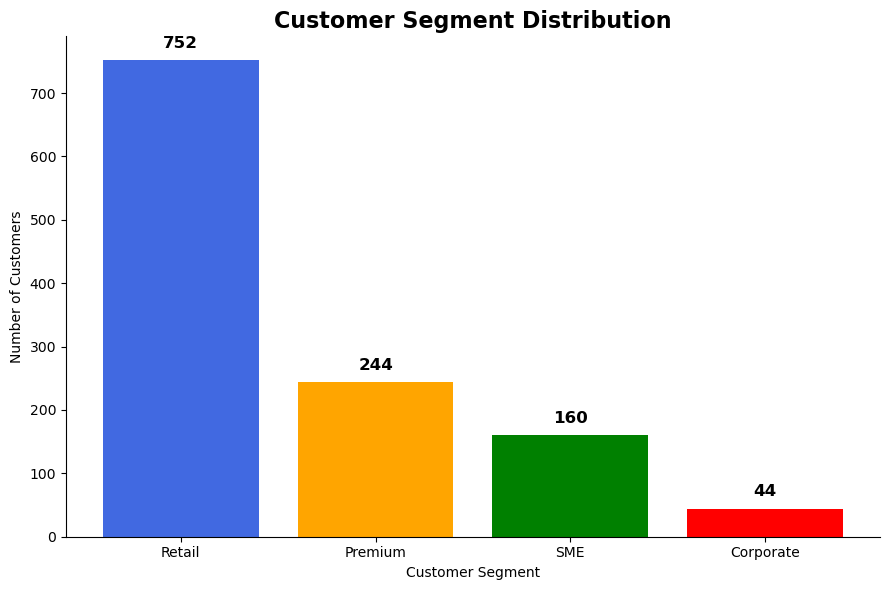

In [24]:
# Chart 15: Customer Segment Distribution

segment_counts = customers["customer_segment"].value_counts()

# Different colors
colors = ["royalblue", "orange", "green", "red"]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
    color=colors[:len(segment_counts)]
)

# Add count labels
for bar, count in zip(bars, segment_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Customer Segment Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Remove grid
plt.grid(False)

# Remove top and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()